# Flat-port ray geometry visualization

Paper reference: §3.3.2 (Flat-port refraction analysis).

Companion to `flat_port_refraction.ipynb`. This notebook draws the
actual refracted light path (camera → air → acrylic → water → fish)
alongside the *estimated* unrefracted ray the pinhole camera model
assumes, so the geometric origin of the depth error is visible
directly. Ported from `LaserDepthErrorPaper.m` in the MATLAB
`fishsense-optics-simulator` repo.

At each sampled depth the laser projects a dot onto the fish; the
camera observes that dot along a refracted path but, under the
pinhole assumption of Equation 5, back-projects it as if travelling
in a straight line from the focal point. The offset between the two
rays is the error.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from fishsense_imwut.refraction import (
    FlatPort,
    LASER_CONFIGURATIONS_MM,
    solve_forward_projection,
    trace_refracted_ray,
)

In [2]:
port = FlatPort()
port

FlatPort(d_air=2.0, d_glass=11.56, mu_air=1.0, mu_glass=1.495, mu_water=1.34995)

## Laser configuration

We use the `cam2` configuration from the eight-pose box plot. The
laser origin is ~11 cm offset from the focal point in the $y$
direction and the laser direction is near-parallel to the optical
axis, matching the 3D-printed cold-shoe mount geometry described in
§3.3.3.

In [3]:
_, laser_origin, laser_direction = LASER_CONFIGURATIONS_MM[0]
laser_direction = laser_direction / np.linalg.norm(laser_direction)
laser_origin, laser_direction

(array([-30.90316, -99.5172 ,   0.     ]),
 array([0.03036568, 0.03888115, 0.99878235]))

## Sampled depths

Five depths from 1 m to 5 m. Each produces one fish point, one
refracted camera path, and one pinhole estimate.

In [4]:
depths_mm = np.array([1000, 2000, 3000, 4000, 5000])
depths_mm

array([1000, 2000, 3000, 4000, 5000])

## Projection plane

Because the interfaces are parallel and perpendicular to the optical
axis, every ray in this simulation lies in the plane spanned by the
optical axis and the fish point (the "plane of refraction"). Plotting
in that 2D plane avoids a cluttered 3D figure: the horizontal axis is
$z$ (depth from camera), the vertical axis is the signed radial
distance from the optical axis. We use the fish's azimuth from the
first laser configuration to define the sign.

In [5]:
sample_fish = laser_origin + (depths_mm[-1] - laser_origin[2]) / laser_direction[2] * laser_direction
u_hat = np.array([sample_fish[0], sample_fish[1], 0.0])
u_hat = u_hat / np.linalg.norm(u_hat)

def project(p):
    return p[2], p[0] * u_hat[0] + p[1] * u_hat[1]

## Figure

Blue solid: actual refracted path (camera → air–glass → glass–water →
fish). Black dashed: pinhole estimate (camera → reconstructed fish
point from Equation 5 applied to the refracted air-side direction).
The gap at the fish depth is the estimation error.

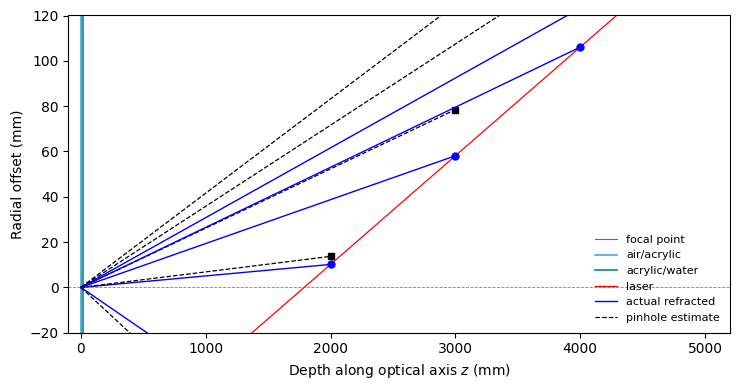

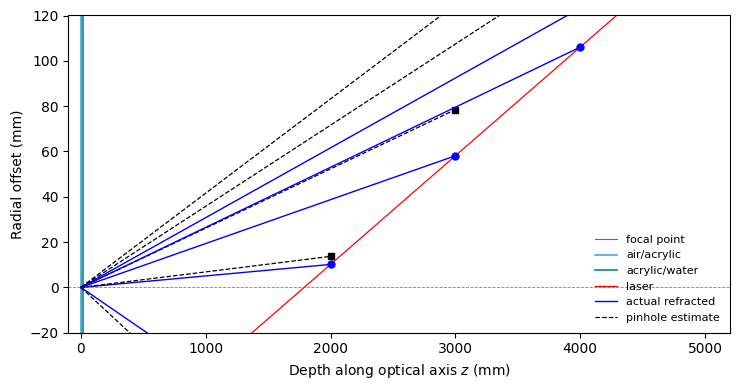

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.0))

# Interface planes.
max_u_plot = 120.0
ax.axvline(0.0, color="magenta", linewidth=0.8, label="focal point")
ax.axvline(port.d_air, color="#4daadd", linewidth=1.2, label="air/acrylic")
ax.axvline(port.d_air + port.d_glass, color="#008b8b", linewidth=1.2,
           label="acrylic/water")

# Optical axis.
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.6)

# Laser ray (extend to furthest depth).
t_end = (depths_mm[-1] - laser_origin[2]) / laser_direction[2]
laser_end = laser_origin + t_end * laser_direction
z0, u0 = project(laser_origin)
z1, u1 = project(laser_end)
ax.plot([z0, z1], [u0, u1], color="red", linewidth=0.9, label="laser")
ax.plot([z0], [u0], marker="*", color="red", markersize=10)

first_actual = True
first_estimate = True

for w in depths_mm:
    fish = laser_origin + (w - laser_origin[2]) / laser_direction[2] * laser_direction
    v_air = solve_forward_projection(fish, port)
    p1, p2, p3 = trace_refracted_ray(v_air, fish[2], port)

    zs = [0.0, p1[2], p2[2], p3[2]]
    us = [0.0, project(p1)[1], project(p2)[1], project(p3)[1]]
    ax.plot(zs, us, color="blue", linewidth=1.0,
            label="actual refracted" if first_actual else None)
    ax.plot([project(fish)[0]], [project(fish)[1]], marker="o", color="blue", markersize=5)
    first_actual = False

    # Pinhole estimate: extend v_air as a straight line until we reach the fish depth.
    t_est = fish[2] / v_air[2]
    p_est = t_est * v_air
    ax.plot([0.0, p_est[2]], [0.0, project(p_est)[1]],
            color="black", linestyle="--", linewidth=0.9,
            label="pinhole estimate" if first_estimate else None)
    ax.plot([project(p_est)[0]], [project(p_est)[1]], marker="s", color="black", markersize=4)
    first_estimate = False

ax.set_xlabel("Depth along optical axis $z$ (mm)")
ax.set_ylabel("Radial offset (mm)")
ax.set_xlim(-100, depths_mm[-1] + 200)
ax.set_ylim(-20, max_u_plot)
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig

At near distances the estimate lies closer to the camera than the
true fish; at far distances it overshoots. The single depth where the
two rays coincide is the zero-crossing in the per-configuration
scatter plot of `flat_port_refraction.ipynb` — exactly one such
crossing per configuration. The refraction bias is not a simple
offset the calibration can absorb, which is why the flat port needs
an optical correction rather than a software one.